In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def get_df(band="gamma"):
    df_mu_10 = pd.read_csv(f'resultados_rqa_{band}/carga_10_{band}.csv')
    df_mu_5 = pd.read_csv(f'resultados_rqa_{band}/carga_5_{band}.csv')
    df_mu_0 = pd.read_csv(f'resultados_rqa_{band}/carga_0_{band}.csv')
    df_mu_0.drop(df_mu_0[df_mu_0["determinism"] == 0].index, inplace=True)
    df_mu_5.drop(df_mu_5[df_mu_5["determinism"] == 0].index, inplace=True)
    df_mu_10.drop(df_mu_10[df_mu_10["determinism"] == 0].index, inplace=True)

    df_mu_0.reset_index(drop=True, inplace=True)
    df_mu_5.reset_index(drop=True, inplace=True)
    df_mu_10.reset_index(drop=True, inplace=True)
    

    df_mu_10_norep = df_mu_10[df_mu_10["Binaria"] > 0.5].reset_index(drop=True)
    df_mu_10_norep = df_mu_10_norep.drop(columns=['banda', 'archivo', 'sujeto', 'sesion'])

    df_mu_5_norep = df_mu_5[df_mu_5["Binaria"] > 0.5].reset_index(drop=True)
    df_mu_5_norep = df_mu_5_norep.drop(columns=['banda', 'archivo', 'sujeto', 'sesion'])

    df_mu_0_norep = df_mu_0[df_mu_0["Binaria"] > 0.5].reset_index(drop=True)
    df_mu_0_norep = df_mu_0_norep.drop(columns=['banda', 'archivo', 'sujeto', 'sesion'])


    # Elegimos el número de muestras que queremos (por ejemplo, el mínimo entre los 3)
    min_len = min(len(df_mu_10_norep), len(df_mu_5_norep), len(df_mu_0_norep))

    # Interpolamos todos
    #df_mu_10_interp = interpolate_df(df_mu_10_norep, min_len)
    #df_mu_5_interp = interpolate_df(df_mu_5_norep, min_len)
    #df_mu_0_interp = interpolate_df(df_mu_0_norep, min_len)

    # Concatenamos todo
    big_df_interp = pd.concat([df_mu_10_norep, df_mu_5_norep, df_mu_0_norep], ignore_index=True)

    #big_df_interp["condicion"] = big_df_interp["condicion"].replace({
    #    "10% Torque": 10,
    #    "5% Torque": 5,
    #    "0% Torque": 0
    #})
    return big_df_interp

In [3]:
big_mu = get_df(band="mu")
big_beta = get_df(band="beta")
big_gamma = get_df(band="gamma")

In [4]:
big_beta

,recurrence_rate,determinism,trapping_time,diag_entropy,vert_entropy,laminarity,Binaria,condicion
0,0.383889,0.936460,5.530864,1.754285,2.328612,0.972504,1.0,10% Torque
1,0.416111,0.945758,6.129167,1.897961,2.461873,0.981976,1.0,10% Torque
2,0.353889,0.901153,4.916335,1.824723,2.108134,0.968603,1.0,10% Torque
3,0.343889,0.901528,5.124464,1.763399,2.184467,0.964459,1.0,10% Torque
4,0.325556,0.902878,5.251163,1.603155,2.191159,0.963311,1.0,10% Torque
...,...,...,...,...,...,...,...,...
9271,0.175556,0.916084,3.898734,1.501325,1.649010,0.974684,1.0,0% Torque
9272,0.166111,0.899628,4.291045,1.505764,1.927399,0.961538,1.0,0% Torque
9273,0.305000,0.911368,5.184466,1.633239,2.238422,0.972678,1.0,0% Torque
9274,0.283333,0.860417,4.658654,1.607962,2.105441,0.950000,1.0,0% Torque


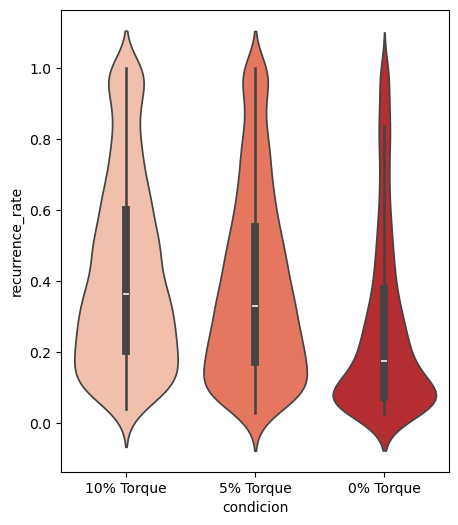

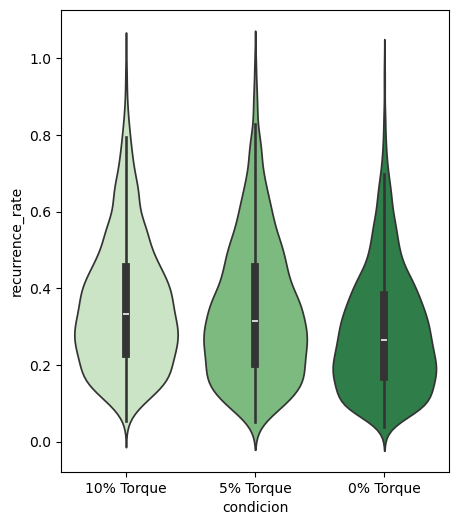

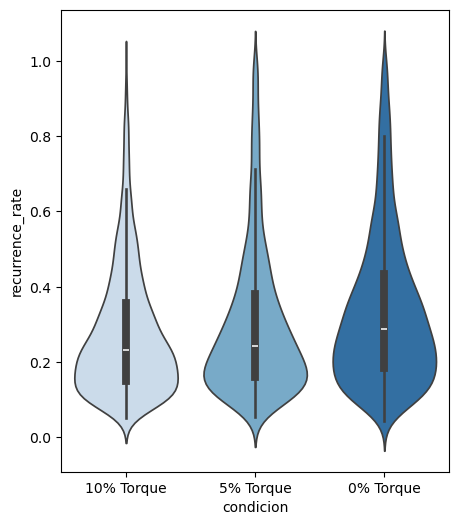

In [22]:
def plot_violoins(df_analisis, label="label", band = "gamma", col = "recurrence_rate"):
    if band == "gamma":
        color = "Blues"
    elif band == "beta":
        color = "Greens"
    elif band == "mu":
        color = "Reds"

    plt.figure(figsize=(5, 6))
    sns.violinplot(x=label, y=col, data=df_analisis, hue=label, fill=True, log_scale=False, alpha=1, palette=color)
    plt.show()

plot_violoins(big_mu, label="condicion", band="mu", col="recurrence_rate")
plot_violoins(big_beta, label="condicion", band="beta", col="recurrence_rate")
plot_violoins(big_gamma, label="condicion", band="gamma", col="recurrence_rate")

In [6]:
big_mu.columns

Index(['recurrence_rate', 'determinism', 'trapping_time', 'diag_entropy',
       'vert_entropy', 'laminarity', 'Binaria', 'condicion'],
      dtype='object')

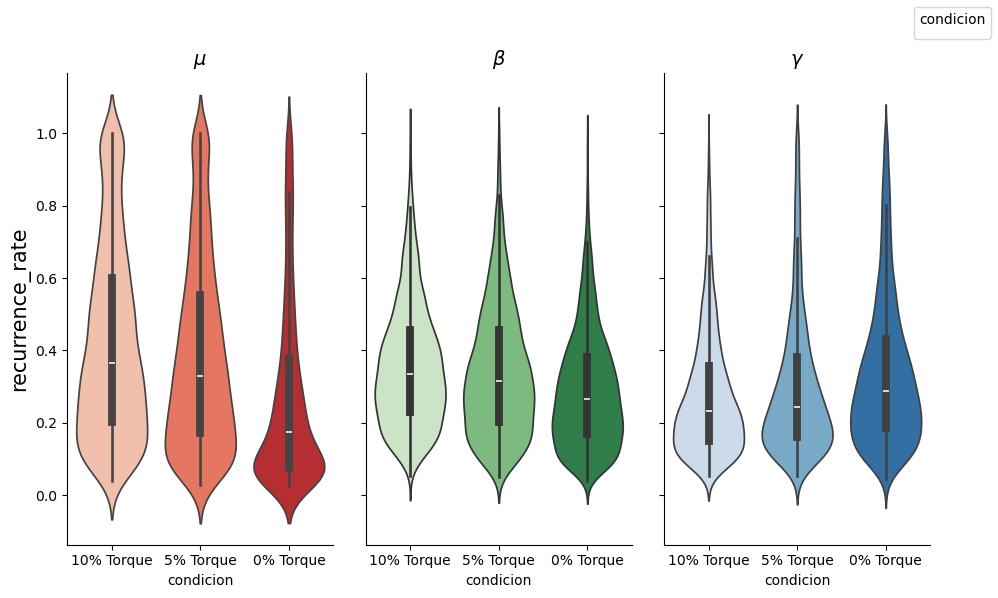

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_violins_side_by_side(big_mu, big_beta, big_gamma, label="condicion", col="recurrence_rate"):
    bands = {
        "mu": (big_mu, "Reds"),
        "beta": (big_beta, "Greens"),
        "gamma": (big_gamma, "Blues"),
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(10, 6), sharey=True)
    
    for ax, (band, (df, color)) in zip(axes, bands.items()):
        sns.violinplot(
            x=label, 
            y=col, 
            data=df, 
            hue=label, 
            fill=True, 
            log_scale=False, 
            alpha=1, 
            palette=color, 
            ax=ax
        )
        ax.set_title(f"$\{band}$", fontsize=14)
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
        ax.set_ylabel(f"{col}", fontsize=15)
        #ax.legend_.remove()  # remove duplicate legends
    
    # Add one global legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", title=label)
    #fig.suptitle(f"{col}", fontsize=25, weight="bold")
    plt.tight_layout(w_pad=2, rect=[0, 0, 0.95, 0.95])
    plt.show()

# Call once for all
plot_violins_side_by_side(big_mu, big_beta, big_gamma, label="condicion", col="recurrence_rate")


In [8]:

def get_df(band="gamma"):
    df_mu_10 = pd.read_csv(f'resultados_rqa_{band}/carga_10_{band}.csv')
    df_mu_5 = pd.read_csv(f'resultados_rqa_{band}/carga_5_{band}.csv')
    df_mu_0 = pd.read_csv(f'resultados_rqa_{band}/carga_0_{band}.csv')
    df_mu_0.drop(df_mu_0[df_mu_0["determinism"] == 0].index, inplace=True)
    df_mu_5.drop(df_mu_5[df_mu_5["determinism"] == 0].index, inplace=True)
    df_mu_10.drop(df_mu_10[df_mu_10["determinism"] == 0].index, inplace=True)

    df_mu_0.reset_index(drop=True, inplace=True)
    df_mu_5.reset_index(drop=True, inplace=True)
    df_mu_10.reset_index(drop=True, inplace=True)
    
    df_mu_10["Binaria"] = df_mu_10["Binaria"] > 0.5
    df_mu_10.drop(columns=['banda', 'archivo', 'sujeto', 'sesion', 'condicion'], inplace=True)  

    df_mu_5["Binaria"] = df_mu_5["Binaria"] > 0.5
    
    df_mu_5.drop(columns=['banda', 'archivo', 'sujeto','sesion', 'condicion'], inplace=True)
    df_mu_0["Binaria"] = df_mu_0["Binaria"] > 0.5

    df_mu_0.drop(columns=['banda', 'archivo', 'sujeto', 'sesion', 'condicion'], inplace=True)

    return df_mu_10, df_mu_5, df_mu_0



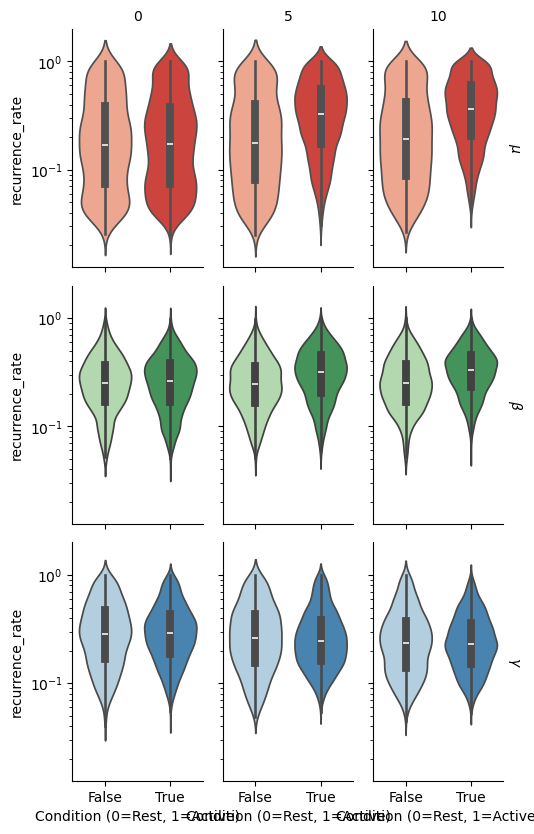

In [9]:
mu_10, mu_5, mu_0 = get_df("mu")
beta_10, beta_5, beta_0 = get_df("beta")
gamma_10, gamma_5, gamma_0 = get_df("gamma")

var = "recurrence_rate"

def add_meta(df, band, torque):
    df = df.copy()
    df["band"] = band
    df["torque"] = torque
    return df

dfs = [
    add_meta(mu_10, "mu", 10), add_meta(mu_5, "mu", 5), add_meta(mu_0, "mu", 0),
    add_meta(beta_10, "beta", 10), add_meta(beta_5, "beta", 5), add_meta(beta_0, "beta", 0),
    add_meta(gamma_10, "gamma", 10), add_meta(gamma_5, "gamma", 5), add_meta(gamma_0, "gamma", 0),
]

df_all = pd.concat(dfs, axis=0)

# 🎨 paleta por banda
band_colors = {"mu": "Reds", "beta": "Greens", "gamma": "Blues"}

# graficar
g = sns.FacetGrid(
    df_all, 
    row="band", col="torque", 
    margin_titles=True, 
    despine=True, 
    height=3, aspect=0.6,
    sharey=True
)

def violin(data, color, **kwargs):
    palette = band_colors[data["band"].iloc[0]]
    sns.violinplot(
        x="Binaria", 
        y=var, 
        data=data, 
        hue="Binaria",
        split=False, 
        log_scale=True,
        palette=sns.color_palette(palette, 2), # más claro/oscuro
        **kwargs
    )

g.map_dataframe(violin)

# títulos y ejes
for ax in g.axes.flatten():
    ax.set_xlabel("Condition (0=Rest, 1=Active)")
    ax.set_ylabel(f"{var}")

g.set_titles(row_template="$\{row_name}$", col_template="{col_name}")
#g.add_legend(title="Condition (Binaria)")

plt.subplots_adjust(top=0.9)
#g.fig.suptitle("Recurrence Rate across bands and torque", fontsize=16, weight="bold")
plt.show()

ESTADÍSTICAS DETALLADAS - RECURRENCE_RATE

MU BAND:
----------------------------------------
10% Torque: n=3074, mean=0.4228, std=0.2649, median=0.3644
5% Torque: n=3001, mean=0.3872, std=0.2617, median=0.3289
0% Torque: n=3201, mean=0.2715, std=0.2550, median=0.1744

Pruebas t pareadas:
  10% Torque vs 5% Torque: t=5.260, p=0.000000
  10% Torque vs 0% Torque: t=23.052, p=0.000000
  5% Torque vs 0% Torque: t=17.639, p=0.000000

BETA BAND:
----------------------------------------
10% Torque: n=3074, mean=0.3578, std=0.1686, median=0.3336
5% Torque: n=3001, mean=0.3435, std=0.1791, median=0.3150
0% Torque: n=3201, mean=0.2905, std=0.1585, median=0.2644

Pruebas t pareadas:
  10% Torque vs 5% Torque: t=3.198, p=0.001392
  10% Torque vs 0% Torque: t=16.295, p=0.000000
  5% Torque vs 0% Torque: t=12.361, p=0.000000

GAMMA BAND:
----------------------------------------
10% Torque: n=3074, mean=0.2772, std=0.1684, median=0.2322
5% Torque: n=3001, mean=0.3022, std=0.1963, median=0.2433
0% Torq

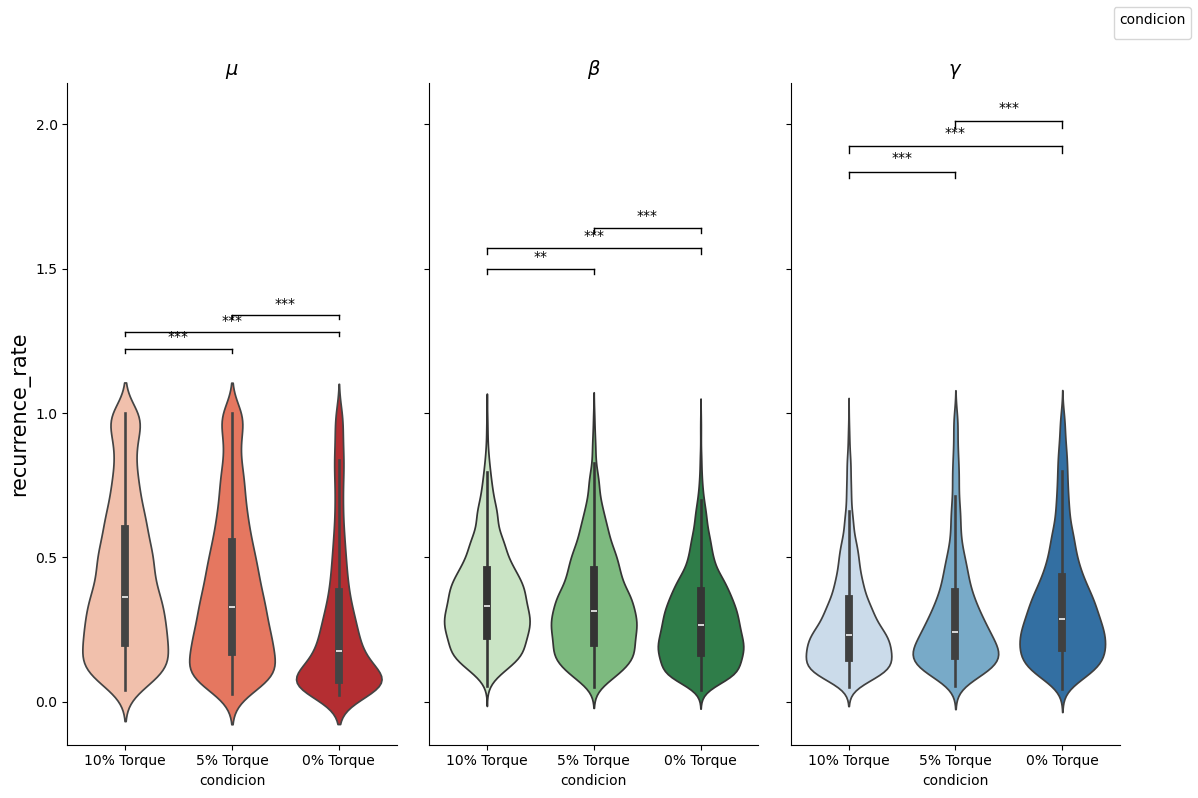

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
from itertools import combinations

def plot_violins_side_by_side(big_mu, big_beta, big_gamma, label="condicion", col="recurrence_rate"):
    bands = {
        "mu": (big_mu, "Reds"),
        "beta": (big_beta, "Greens"),
        "gamma": (big_gamma, "Blues"),
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True)
    
    # Diccionario para almacenar los datos de cada banda por condición
    band_data = {}
    
    for ax, (band, (df, color)) in zip(axes, bands.items()):
        # Almacenar datos para las pruebas estadísticas
        band_data[band] = {}
        for condition in df[label].unique():
            band_data[band][condition] = df[df[label] == condition][col].values
        
        sns.violinplot(
            x=label, 
            y=col, 
            data=df, 
            hue=label, 
            fill=True, 
            log_scale=False, 
            alpha=1, 
            palette=color, 
            ax=ax
        )
        ax.set_title(f"$\\{band}$", fontsize=14)
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
        ax.set_ylabel(f"{col}", fontsize=15)
        
        # Realizar pruebas t entre todas las condiciones dentro de cada banda
        conditions = list(band_data[band].keys())
        y_max = ax.get_ylim()[1]
        y_offset = y_max * 0.05
        
        # Calcular todas las combinaciones de pares de condiciones
        condition_pairs = list(combinations(conditions, 2))
        
        for i, (cond1, cond2) in enumerate(condition_pairs):
            data1 = band_data[band][cond1]
            data2 = band_data[band][cond2]
            
            # Realizar prueba t
            t_stat, p_value = stats.ttest_ind(data1, data2)
            
            # Determinar significancia
            if p_value < 0.001:
                sig_text = "***"
            elif p_value < 0.01:
                sig_text = "**"
            elif p_value < 0.05:
                sig_text = "*"
            else:
                sig_text = "ns"
            
            # Posiciones para las líneas de significancia
            x1, x2 = conditions.index(cond1), conditions.index(cond2)
            y_pos = y_max + y_offset * (i + 1)
            
            # Dibujar líneas de significancia
            ax.plot([x1, x2], [y_pos, y_pos], 'k-', linewidth=1)
            ax.plot([x1, x1], [y_pos - y_offset/4, y_pos], 'k-', linewidth=1)
            ax.plot([x2, x2], [y_pos - y_offset/4, y_pos], 'k-', linewidth=1)
            
            # Agregar texto de significancia
            ax.text((x1 + x2) / 2, y_pos + y_offset/4, sig_text, 
                   ha='center', va='bottom', fontsize=10)
        
        # Ajustar límites del eje y para acomodar las anotaciones
        ax.set_ylim(ax.get_ylim()[0], y_max + y_offset * (len(condition_pairs) + 1.5))
    
    # Add one global legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", title=label)
    
    plt.tight_layout(w_pad=2, rect=[0, 0, 0.95, 0.95])
    
    # Imprimir estadísticas detalladas
    print("="*80)
    print(f"ESTADÍSTICAS DETALLADAS - {col.upper()}")
    print("="*80)
    
    for band in bands.keys():
        print(f"\n{band.upper()} BAND:")
        print("-" * 40)
        
        # Estadísticas descriptivas
        conditions = list(band_data[band].keys())
        for condition in conditions:
            data = band_data[band][condition]
            print(f"{condition}: n={len(data)}, mean={np.mean(data):.4f}, "
                  f"std={np.std(data, ddof=1):.4f}, median={np.median(data):.4f}")
        
        print("\nPruebas t pareadas:")
        condition_pairs = list(combinations(conditions, 2))
        for cond1, cond2 in condition_pairs:
            data1 = band_data[band][cond1]
            data2 = band_data[band][cond2]
            t_stat, p_value = stats.ttest_ind(data1, data2)
            print(f"  {cond1} vs {cond2}: t={t_stat:.3f}, p={p_value:.6f}")
    
    # ANOVA entre todas las bandas para cada condición
    print(f"\n\nANOVA ENTRE BANDAS:")
    print("-" * 40)
    
    all_conditions = set()
    for band_dict in band_data.values():
        all_conditions.update(band_dict.keys())
    
    for condition in all_conditions:
        # Recopilar datos de todas las bandas para esta condición
        condition_data = []
        band_labels = []
        
        for band, data_dict in band_data.items():
            if condition in data_dict:
                condition_data.extend(data_dict[condition])
                band_labels.extend([band] * len(data_dict[condition]))
        
        if len(set(band_labels)) > 1:  # Solo si hay datos de múltiples bandas
            # Preparar datos para ANOVA
            groups = []
            for band in ['mu', 'beta', 'gamma']:
                if condition in band_data[band]:
                    groups.append(band_data[band][condition])
            
            if len(groups) > 1:
                f_stat, p_value_anova = stats.f_oneway(*groups)
                print(f"{condition}: F={f_stat:.3f}, p={p_value_anova:.6f}")
    
    plt.show()

# Call once for all
plot_violins_side_by_side(big_mu, big_beta, big_gamma, label="condicion", col="recurrence_rate")